<a href="https://colab.research.google.com/github/arivine/data-science-2026/blob/main/Pertemuan_4_Muhammad_Arifin_230401010367.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  Identitas Mahasiswa
* **Nama Lengkap:** Muhammad Arifin
* **NIM:** 230401010367
* **Kelas:** IF 401
* **Program Studi:** PJJ Informatika

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print("\n--- Tipe Data ---")
print(df.dtypes)
print("\n--- 5 Data Pertama ---")
print(df.head())
print("\n--- Deskripsi Ringkas ---")
print(df.describe().round(3))

Shape: (150, 5)

--- Tipe Data ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- 5 Data Pertama ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Deskripsi Ringkas ---
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000    

In [2]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean     : 5.843
 Median   : 5.800
 Std Dev  : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean     : 3.057
 Median   : 3.000
 Std Dev  : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean     : 3.758
 Median   : 4.350
 Std Dev  : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean     : 1.199
 Median   : 1.300
 Std Dev  : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


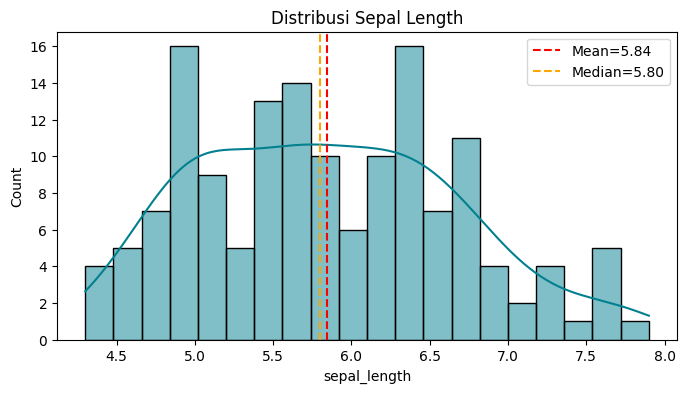

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

/tmp/ipykernel_1692/603639068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_1692/603639068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


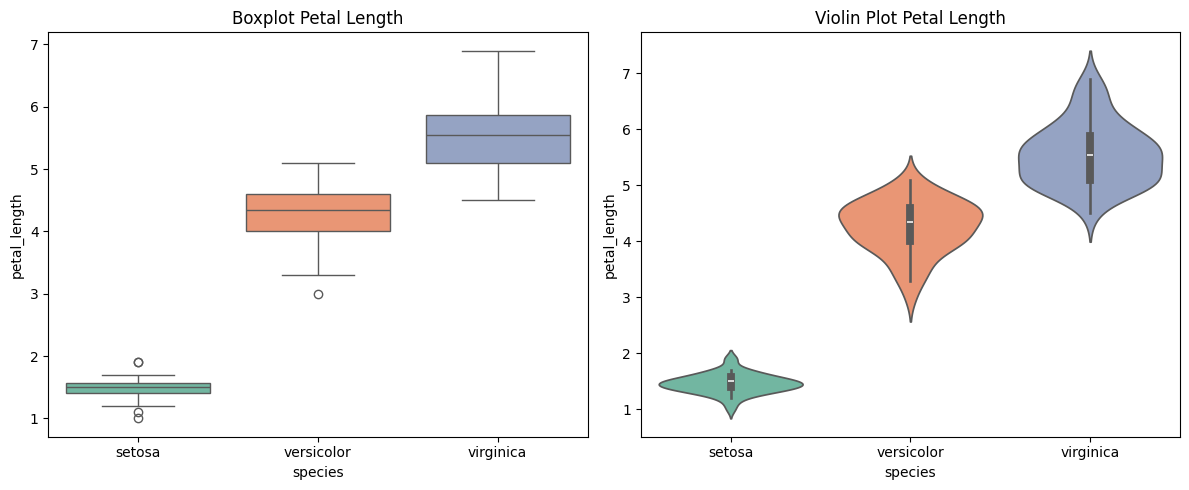

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

In [5]:
corr = df.drop('species', axis=1).corr(method='pearson')
print("--- Matriks Korelasi Pearson ---")
print(corr.round(3))
print("\n--- Pasangan Korelasi Tertinggi ---")
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

--- Matriks Korelasi Pearson ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

--- Pasangan Korelasi Tertinggi ---
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


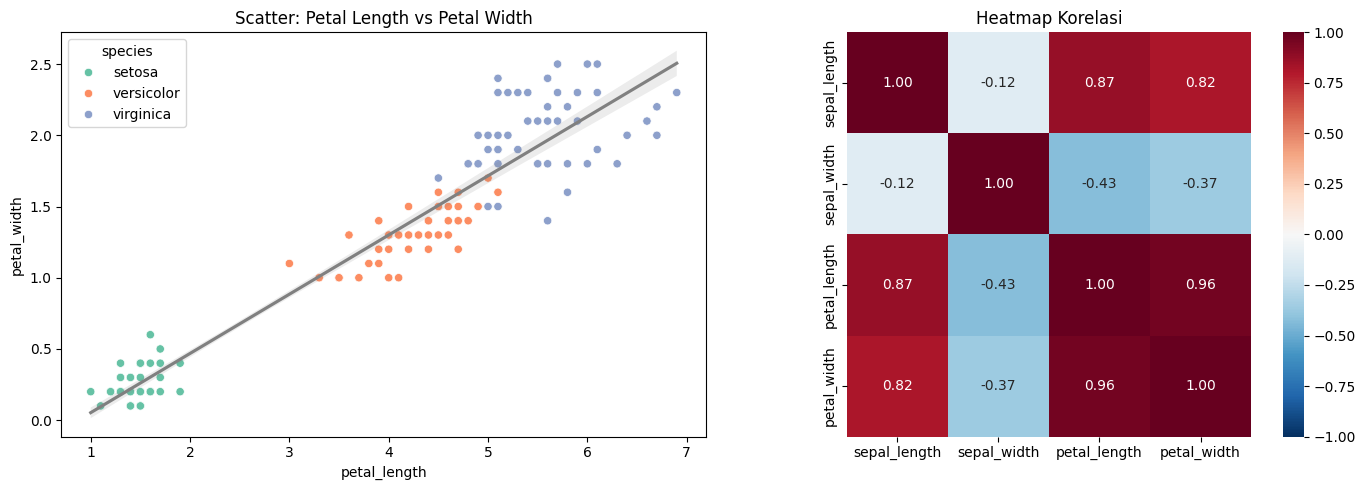

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

##  Kesimpulan Pertemuan 4

* **Apa yang dipelajari:** Menerapkan statistika deskriptif (mengukur pemusatan dan penyebaran data) serta melakukan visualisasi data (*distribution & relationship plots*) menggunakan library Seaborn dan Matplotlib pada dataset Iris.
* **Temuan Utama:** Ditemukan korelasi linier positif yang sangat kuat antara fitur `petal_width` dan `petal_length` dengan nilai Pearson sebesar 0.963. Visualisasi *Boxplot* dan *Violin Plot* juga menunjukkan bahwa spesies *Setosa* memiliki karakteristik ukuran kelopak (*petal*) yang jauh lebih kecil dan terpisah jelas dibandingkan dengan spesies *Versicolor* dan *Virginica*.
